# RQ2 — What's the Trend? (Quarterly Download/Upload/Latency, 2023Q1–2025Q4)

RQ1 (`rq1_thresholds_ookla.ipynb`, `rq1_thresholds_ndt7.ipynb`) asked a snapshot question — how
does SEA broadband measure up against app-requirement thresholds. RQ2 asks the time dimension: is
it **getting better, worse, or flat** over the 12 quarters we have data for (2023-Q1 to 2025-Q4)?

Method follows the **Fig. 7 template from Lübben & Misfeld (2022)** — median line with 25th/75th
percentile band per period, per segment — adapted from their monthly TCP-protocol view to our
quarterly view.

This notebook has two parts:

- **Part A — SEA-wide trend, 8 countries, equal footing.** Ookla fixed, download growth compared
  across all 8 study countries with no country singled out — the primary answer to "what's the
  regional trend."
- **Part B — Thailand & Vietnam platform deep-dive (Ookla vs NDT7).** Limited to these 2 countries
  because NDT7 data doesn't exist for the other 6 (data-availability constraint, not a scope
  choice — see `docs/paper_draft.md` §1.3/2.2). Covers download/upload/latency trend across all
  4 available segments (Ookla fixed/mobile, NDT7 fixed/mobile) and a province-level drilldown
  (Bangkok metro mobile) that only this pair of countries has the sample to support.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

SEGMENTS = {
    'Ookla fixed':  'ookla_province_quarterly.csv',
    'Ookla mobile': 'ookla_mobile_province_quarterly.csv',
    'NDT7 fixed':   'ndt7_broadband_thailand_reliable_province_quarterly.csv',
    'NDT7 mobile':  'ndt7_mobile_thailand_reliable_province_quarterly.csv',
}
COLORS = {
    'Ookla fixed':  '#0072B2',
    'Ookla mobile': '#56B4E9',
    'NDT7 fixed':   '#D55E00',
    'NDT7 mobile':  '#E69F00',
}
QUARTERS = [f'{y}-Q{q}' for y in (2023, 2024, 2025) for q in (1, 2, 3, 4)]

frames = []
for seg, fname in SEGMENTS.items():
    d = pd.read_csv(EXPORTS / fname)
    d['segment'] = seg
    frames.append(d)
all_df = pd.concat(frames, ignore_index=True)
all_df['quarter'] = pd.Categorical(all_df['quarter'], categories=QUARTERS, ordered=True)
all_df.shape

(2446, 16)

## Part A — SEA-Wide Quarterly Trend (8 Countries, Equal Comparison)

Extends RQ1's cross-country snapshot to the time dimension: does Thailand's download growth look
typical, ahead, or behind its neighbors' own growth over the same 12 quarters — and how does
every other country compare to every other country, not just to Thailand?

**Scope**: Ookla fixed, download only (mobile/upload/latency cross-country trend deferred — not
core to this pass). NDT7 is out of scope here regardless (only Thailand + Vietnam have NDT7
data — covered in Part B instead).

In [2]:
COUNTRY_FILES = {
    'Thailand':    'ookla_province_quarterly.csv',
    'Vietnam':     'ookla_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_philippines_province_quarterly.csv',
    'Singapore':   'ookla_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_cambodia_province_quarterly.csv',
    'Laos':        'ookla_laos_province_quarterly.csv',
    'Malaysia':    'ookla_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_myanmar_province_quarterly.csv',
}

country_frames = []
for country, fname in COUNTRY_FILES.items():
    d = pd.read_csv(EXPORTS / fname)
    d['country'] = country
    country_frames.append(d)
sea_df = pd.concat(country_frames, ignore_index=True)
sea_df['quarter'] = pd.Categorical(sea_df['quarter'], categories=QUARTERS, ordered=True)

# same 2025-Q3 export gap affects all 8 countries identically -- not a Thailand-specific artifact
sea_df.groupby('country', observed=True)['quarter'].apply(lambda s: sorted(set(QUARTERS) - set(s)))

country
Cambodia       []
Laos           []
Malaysia       []
Myanmar        []
Philippines    []
Singapore      []
Thailand       []
Vietnam        []
Name: quarter, dtype: object

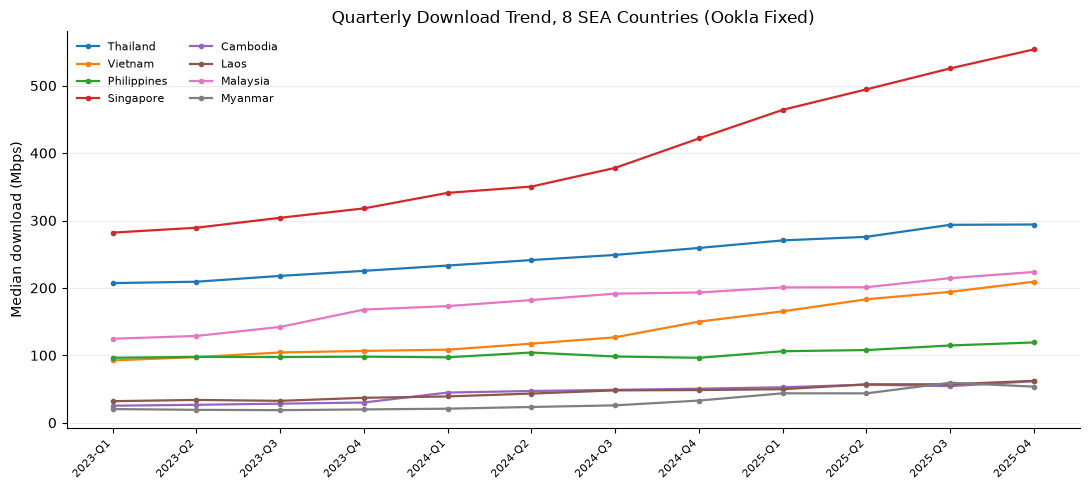

quarter,2023-Q1,2025-Q4,pct_growth
country,,,
Myanmar,20.3,53.6,163.8
Cambodia,25.3,61.7,144.1
Vietnam,92.4,209.2,126.4
Singapore,282.0,553.8,96.4
Laos,32.0,62.2,94.4
Malaysia,124.6,223.6,79.5
Thailand,207.1,294.0,42.0
Philippines,96.4,119.1,23.6


In [3]:
d_by_country = (
    sea_df.groupby(['country', 'quarter'], observed=True)['avg_d_mbps']
    .median().reset_index(name='median_d_mbps')
)

COUNTRY_COLORS = {c: plt.cm.tab10(i) for i, c in enumerate(COUNTRY_FILES)}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(QUARTERS))
for country in COUNTRY_FILES:
    s = d_by_country[d_by_country['country'] == country].set_index('quarter').reindex(QUARTERS)
    ax.plot(x, s['median_d_mbps'], marker='o', markersize=3, label=country,
            color=COUNTRY_COLORS[country], linewidth=1.6)
ax.set_xticks(x)
ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median download (Mbps)')
ax.set_title('Quarterly Download Trend, 8 SEA Countries (Ookla Fixed)')
ax.legend(fontsize=8, loc='upper left', ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

growth = (
    d_by_country[d_by_country['quarter'].isin(['2023-Q1', '2025-Q4'])]
    .pivot(index='country', columns='quarter', values='median_d_mbps')
    .assign(pct_growth=lambda d: (d['2025-Q4'] / d['2023-Q1'] - 1) * 100)
    .sort_values('pct_growth', ascending=False)
    .round(1)
)
growth

**SEA growth-context findings.** Thailand's +42.0% download growth (2023-Q1 → 2025-Q4) is the
**2nd-slowest of the 8 countries** — only the Philippines (+23.6%) grows slower:

| Country | 2023-Q1 | 2025-Q4 | % growth |
|---|---|---|---|
| Myanmar | 20.3 | 53.6 | +163.8% |
| Cambodia | 25.3 | 61.7 | +144.1% |
| Vietnam | 92.4 | 209.2 | +126.4% |
| Singapore | 282.0 | 553.8 | +96.4% |
| Laos | 32.0 | 62.2 | +94.4% |
| Malaysia | 124.6 | 223.6 | +79.5% |
| **Thailand** | **207.1** | **294.0** | **+42.0%** |
| Philippines | 96.4 | 119.1 | +23.6% |

This is **not** a sign Thailand is falling behind — it's the flip side of RQ1's finding that
Thailand already clears every speed threshold in this dataset with no headroom to gain from.
The four fastest-growing countries (Myanmar, Cambodia, Vietnam, Laos) are all growing off a much
lower 2023 base (20-92 Mbps) — classic catch-up growth. Singapore, the only country starting
*above* Thailand (282 Mbps in 2023-Q1), still posts +96.4%, more than double Thailand's rate,
which tempers the "Thailand is just plateauing at a high base" read somewhat — Singapore shows a
high base doesn't mechanically cap growth. Malaysia (+79.5%, base 125 Mbps) growing nearly 2x
faster than Thailand from a lower base is the one comparison that doesn't fit the pure
base-effect story and is worth a specific look in the Discussion section (ISP/infrastructure
investment cycle, not just diminishing-returns economics).

**Bottom line: Thailand's absolute download level stays 2nd-highest of the 8 (behind only
Singapore) throughout the entire period — the slower % growth reflects a high starting point,
not stagnation or decline.**

### Growth by region — all 8 SEA countries (2023 Q1 → 2025 Q4, Ookla fixed)

Same question as the country-level growth ranking above, one level more granular, for every
country in `sea_df`: which **regions within each country** grew the most on fixed broadband
download speed? One separate figure per country (median + mean side by side), styled to match the
region-growth chart from the Philippines deep-dive (`ndt7_ph_main.ipynb`) for a consistent
cross-country visual grammar. Thailand keeps the curated `REGION_COLORS` used elsewhere in this
notebook and in `ndt7_eda.ipynb`; the other 7 countries get an auto-assigned qualitative palette
over their own region set.

Base/end values are the **median and mean across provinces within a region** (province-quarter
aggregates only, not raw per-test rows like the PH notebook) -- a coarser base than PH's raw-test
median/mean, kept in mind when comparing magnitudes across countries.

**Thin-region caveat:** several countries have regions backed by only 1-2 provinces (all of
Singapore's 5 regions are single-province; some Cambodia regions too) -- median and mean collapse
to the same province there, so those bars are a single data point, not a distribution. Shown
anyway for completeness; read them as illustrative, not statistically robust.

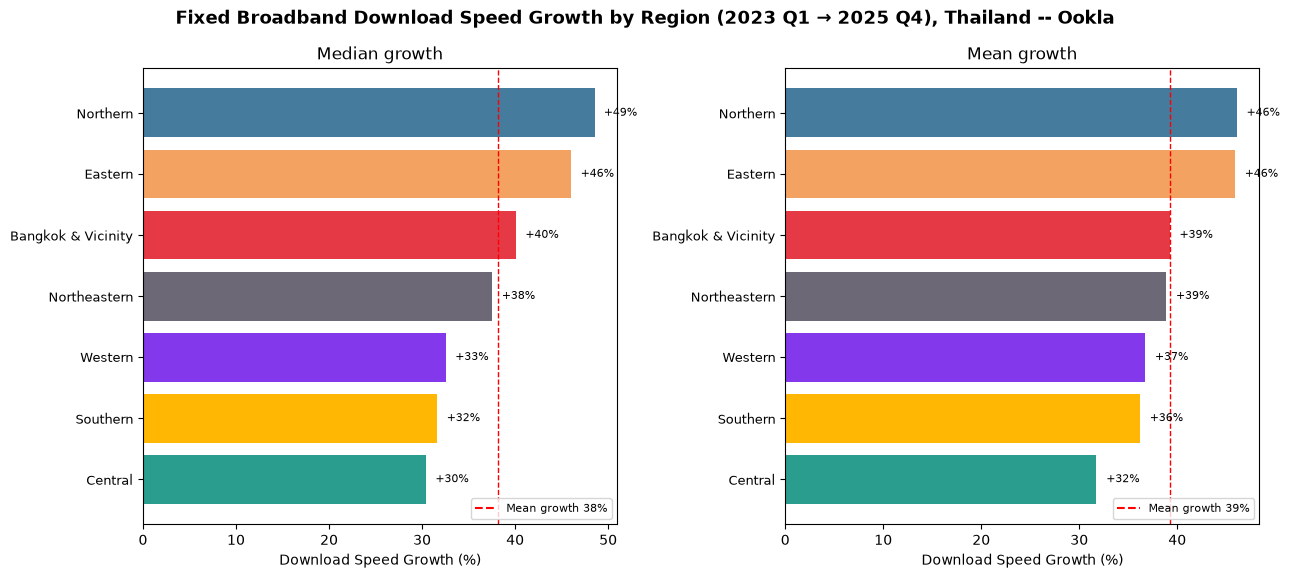

,region,med_base,med_end,median_growth,mean_growth,n_provinces
4,Northern,198.0,294.0,48.5,46.1,17
2,Eastern,221.0,322.8,46.0,45.9,8
0,Bangkok & Vicinity,260.8,365.4,40.1,39.2,6
3,Northeastern,202.7,278.9,37.6,38.9,20
6,Western,231.1,306.4,32.6,36.7,6
5,Southern,195.8,257.7,31.6,36.2,14
1,Central,228.4,297.9,30.4,31.8,6


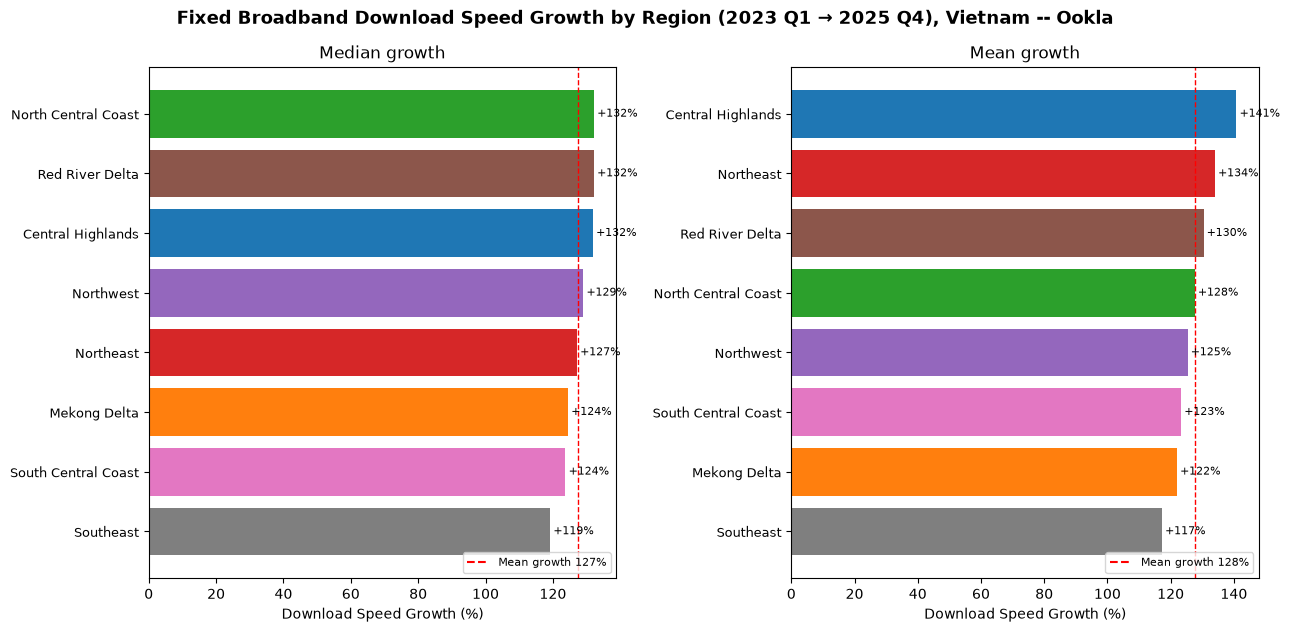

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,North Central Coast,82.1,190.5,132.2,127.6,6
5,Red River Delta,85.8,199.3,132.1,130.4,10
0,Central Highlands,98.9,229.2,131.8,140.8,5
4,Northwest,84.7,193.9,129.0,125.4,6
3,Northeast,88.8,201.6,127.1,134.0,9
1,Mekong Delta,98.4,220.8,124.4,122.0,13
6,South Central Coast,99.4,222.3,123.7,123.3,8
7,Southeast,108.8,238.5,119.1,117.3,7


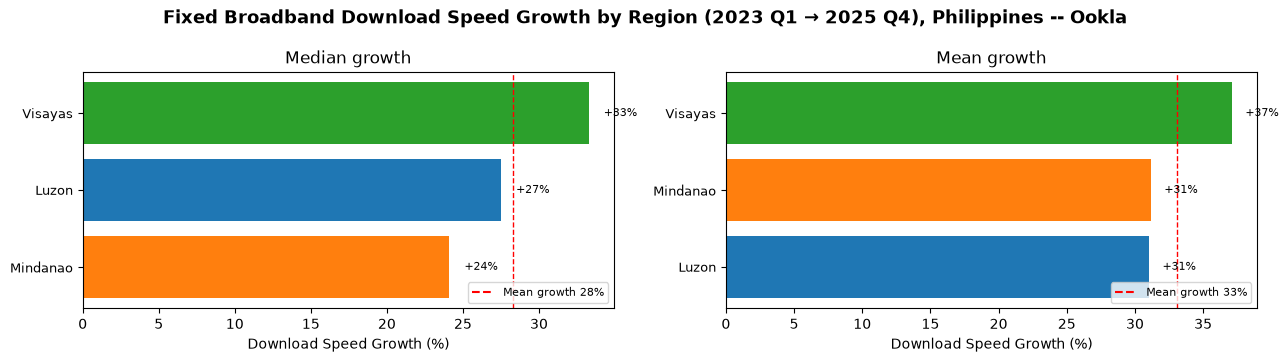

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,Visayas,89.4,119.1,33.3,37.1,3
0,Luzon,104.1,132.7,27.5,31.0,8
1,Mindanao,92.8,115.1,24.1,31.2,6


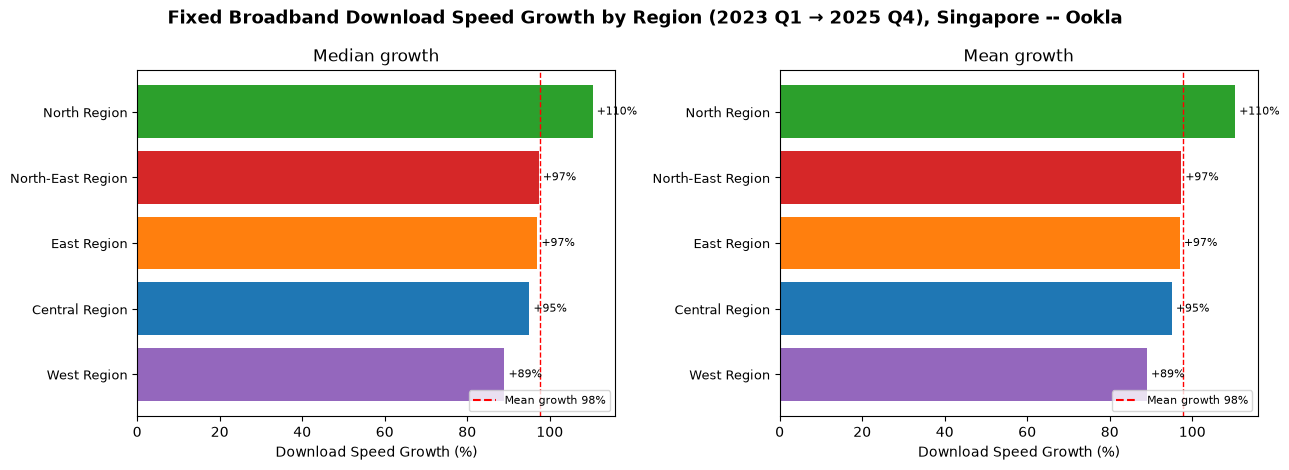

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,North Region,282.0,593.3,110.4,110.4,1
3,North-East Region,286.9,566.1,97.3,97.3,1
1,East Region,281.1,553.8,97.0,97.0,1
0,Central Region,256.0,499.2,95.0,95.0,1
4,West Region,287.9,544.1,89.0,89.0,1


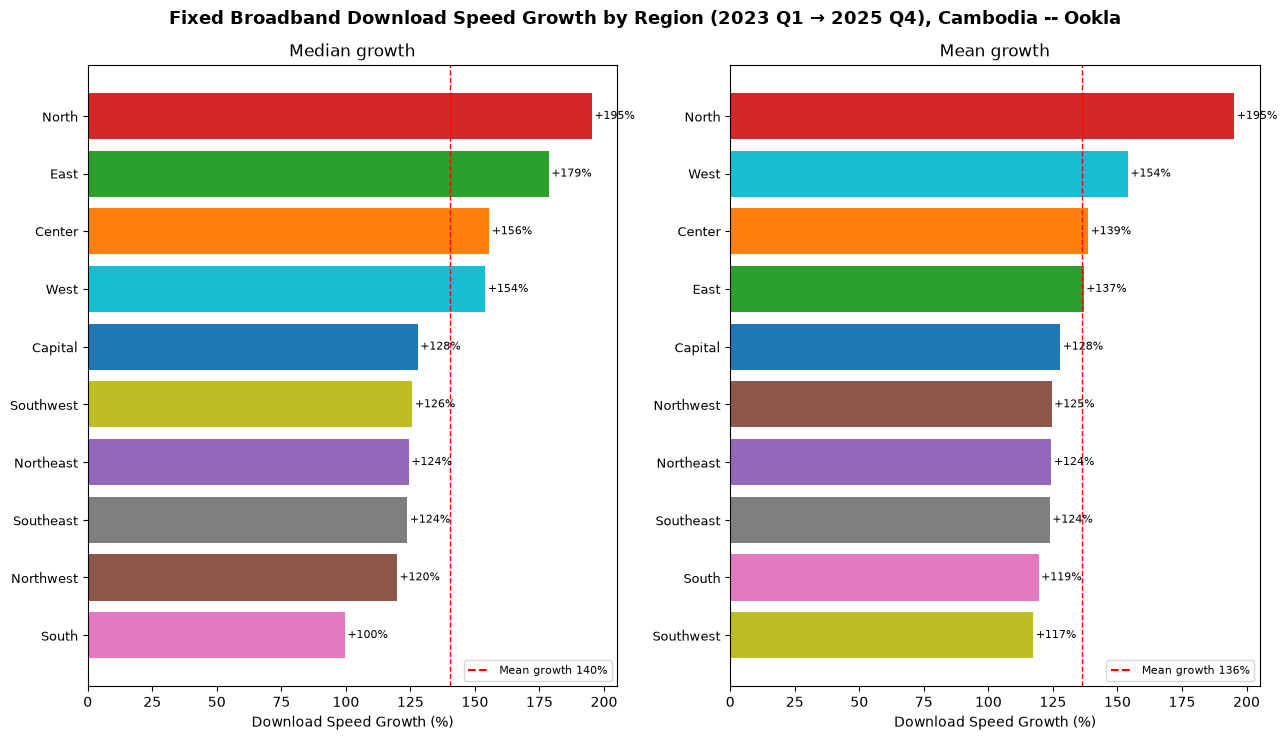

,region,med_base,med_end,median_growth,mean_growth,n_provinces
3,North,18.8,55.6,195.3,195.3,2
2,East,21.5,59.9,178.6,136.9,5
1,Center,23.5,60.0,155.5,138.7,3
9,West,24.5,62.3,154.0,154.0,2
0,Capital,32.4,73.8,127.8,127.8,1
8,Southwest,27.4,61.8,125.8,117.4,3
4,Northeast,25.1,56.3,124.4,124.4,2
7,Southeast,33.6,75.2,123.8,123.8,1
5,Northwest,28.8,63.3,119.8,124.5,3
6,South,30.4,60.6,99.6,119.5,3


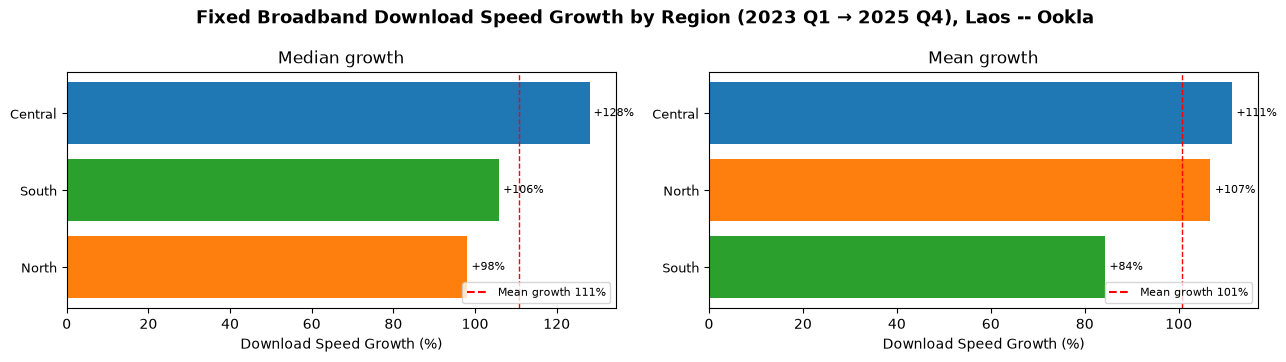

,region,med_base,med_end,median_growth,mean_growth,n_provinces
0,Central,32.8,74.9,128.0,111.3,5
2,South,29.8,61.4,105.9,84.3,5
1,North,31.1,61.5,98.1,106.7,8


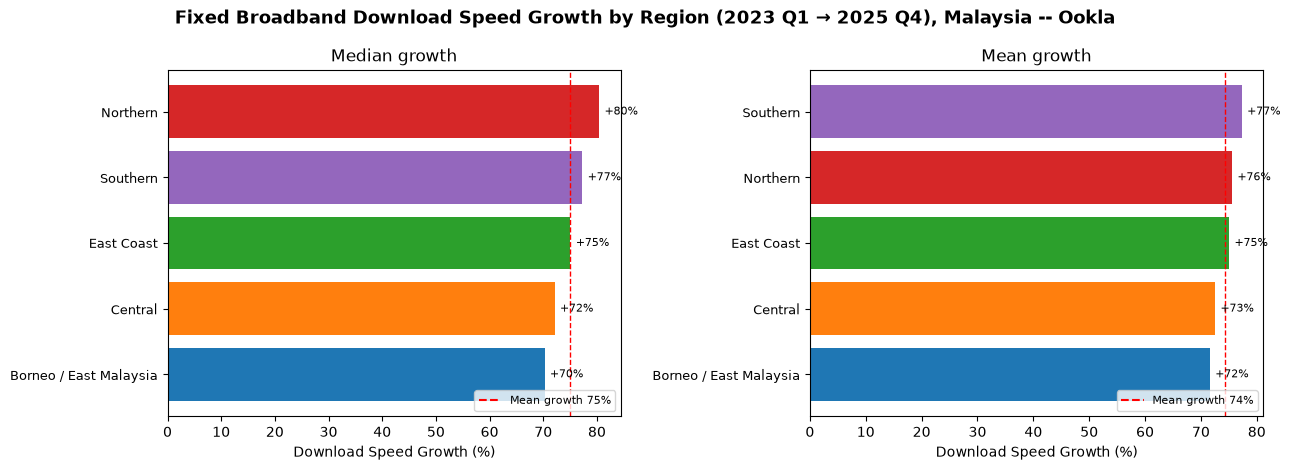

,region,med_base,med_end,median_growth,mean_growth,n_provinces
3,Northern,124.5,224.6,80.4,75.5,4
4,Southern,127.6,226.3,77.3,77.3,2
2,East Coast,114.2,200.0,75.1,75.0,3
1,Central,141.0,242.7,72.1,72.5,4
0,Borneo / East Malaysia,128.6,219.0,70.2,71.6,3


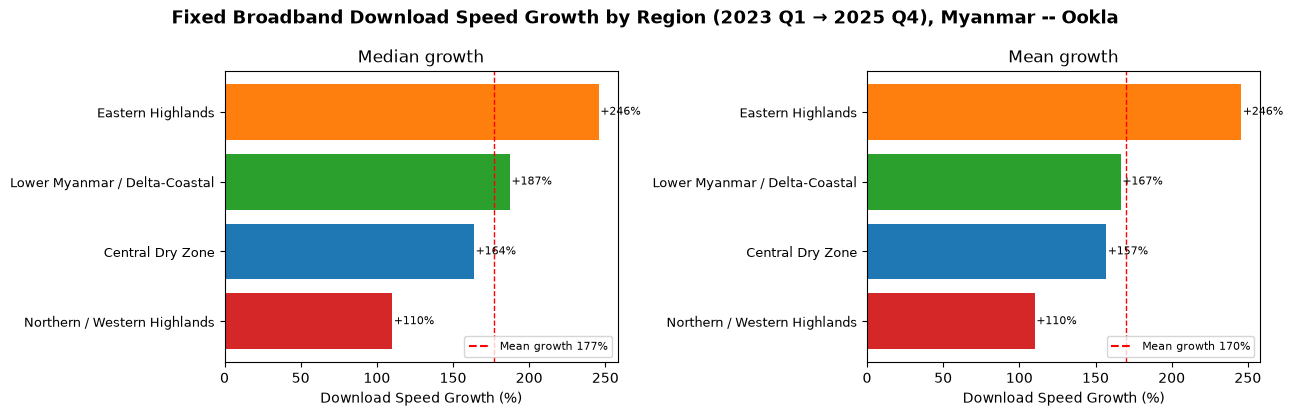

,region,med_base,med_end,median_growth,mean_growth,n_provinces
1,Eastern Highlands,25.0,86.3,245.7,245.7,2
2,Lower Myanmar / Delta-Coastal,21.3,61.1,187.4,166.7,4
0,Central Dry Zone,18.6,49.0,163.9,157.0,3
3,Northern / Western Highlands,16.3,34.3,110.2,110.2,2


In [4]:
def region_growth_chart(df, country):
    sub = df[df['country'] == country]
    prov_growth = (
        sub.pivot_table(index=['province', 'region'], columns='quarter', values='avg_d_mbps', observed=True)
        [['2023-Q1', '2025-Q4']]
        .dropna()
        .reset_index()
    )
    prov_growth.columns = ['province', 'region', 'base', 'end']

    region_growth = (
        prov_growth.groupby('region')
        .agg(med_base=('base', 'median'), med_end=('end', 'median'),
             mean_base=('base', 'mean'), mean_end=('end', 'mean'),
             n_provinces=('province', 'nunique'))
        .reset_index()
    )
    region_growth['median_growth'] = 100 * (region_growth['med_end']  - region_growth['med_base'])  / region_growth['med_base']
    region_growth['mean_growth']   = 100 * (region_growth['mean_end'] - region_growth['mean_base']) / region_growth['mean_base']

    if country == 'Thailand':
        colors = REGION_COLORS
    else:
        palette = plt.cm.tab10.colors + plt.cm.Set3.colors
        colors = {r: palette[i % len(palette)] for i, r in enumerate(sorted(region_growth['region']))}

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 0.55 * len(region_growth) + 2))
    for ax, col, ttl in [(a1, 'median_growth', 'Median growth'), (a2, 'mean_growth', 'Mean growth')]:
        d = region_growth.sort_values(col).reset_index(drop=True)
        y = np.arange(len(d))
        ax.barh(y, d[col], color=[colors[r] for r in d['region']])
        for yi, v in zip(y, d[col]):
            ax.text(v + (1 if v >= 0 else -1), yi, f'{v:+.0f}%',
                    va='center', ha='left' if v >= 0 else 'right', fontsize=8)
        mg = d[col].mean()
        ax.axvline(mg, ls='--', color='red', lw=1)
        ax.set_yticks(y)
        ax.set_yticklabels(d['region'], fontsize=9)
        ax.set_title(ttl)
        ax.set_xlabel('Download Speed Growth (%)')
        ax.legend(handles=[Line2D([0], [0], color='red', ls='--', label=f'Mean growth {mg:.0f}%')],
                  loc='lower right', fontsize=8)

    fig.suptitle(f'Fixed Broadband Download Speed Growth by Region (2023 Q1 → 2025 Q4), {country} -- Ookla',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return region_growth[['region', 'med_base', 'med_end', 'median_growth', 'mean_growth', 'n_provinces']].round(1) \
                         .sort_values('median_growth', ascending=False)


from matplotlib.lines import Line2D

REGION_COLORS = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern':            '#f4a261',
    'Central':            '#2a9d8f',
    'Western':            '#8338ec',
    'Northern':           '#457b9d',
    'Southern':           '#ffb703',
    'Northeastern':       '#6d6875',
}

for country in COUNTRY_FILES:
    table = region_growth_chart(sea_df, country)
    display(table)

## Part B — Thailand & Vietnam Platform Deep-Dive (Ookla vs NDT7)

Four segments, limited to Thailand (all four) and, for cross-validation context, Vietnam where
noted — this is a data-availability limit (NDT7 doesn't exist for the other 6 countries), not a
decision to focus on Thailand over the rest of the region. Part A above is the region-wide answer;
this section is the deeper platform-agreement and sub-national drilldown that only this pair of
countries currently has the sample to support.

| Segment | Export file |
|---|---|
| Ookla fixed | `ookla_province_quarterly.csv` |
| Ookla mobile | `ookla_mobile_province_quarterly.csv` |
| NDT7 fixed (reliable) | `ndt7_broadband_thailand_reliable_province_quarterly.csv` |
| NDT7 mobile (reliable) | `ndt7_mobile_thailand_reliable_province_quarterly.csv` |

### Coverage caveat — sample thins unevenly across segments and time

**Ookla fixed is missing 2025-Q3 entirely** (export gap, not a real-world drop to zero — treat as
a missing point, don't connect the line through it as if measured).

**NDT7 mobile collapses after 2024-Q1**: province coverage per quarter goes
17 → 12 → 12 → 15 → 9 → **2 → 2 → 3 → 3 → 2 → 2 → 2** (2023-Q1 through 2025-Q4). From 2024-Q2
onward the "national" NDT7 mobile median is really just Bangkok Metropolis + 1-2 other provinces
that happened to clear the `total_tests>=100 & n_tiles>=5` reliability bar that quarter — not a
representative national sample. Read the NDT7 mobile line past 2024-Q1 as **indicative, not a
population estimate**.

In [5]:
coverage = (
    all_df.groupby(['segment', 'quarter'], observed=True)
    .agg(n_provinces=('province', 'nunique'), n_tests=('total_tests', 'sum'))
    .reset_index()
)
coverage.pivot(index='quarter', columns='segment', values='n_provinces')

segment,NDT7 fixed,NDT7 mobile,Ookla fixed,Ookla mobile
quarter,,,,
2023-Q1,67,17,77,77
2023-Q2,68,12,77,77
2023-Q3,65,12,77,77
2023-Q4,66,15,77,77
2024-Q1,63,9,77,77
2024-Q2,36,2,77,77
2024-Q3,24,2,77,77
2024-Q4,29,3,77,77
2025-Q1,27,3,77,77


### Trend method

Per segment, per quarter: **median**, **25th percentile**, **75th percentile** of
`avg_d_mbps` / `avg_u_mbps` / `avg_lat_ms_wt` across that quarter's province-level rows
(unweighted across provinces — same convention as Fig. 7, which plots percentiles across
measurement units, not weighted by volume). Province-quarters are the unit here, same as RQ1.

In [6]:
def quarterly_stats(df, col):
    g = df.groupby(['segment', 'quarter'], observed=True)[col]
    out = g.agg(median='median', p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)).reset_index()
    return out

def plot_trend(ax, stats, ylabel):
    for seg in SEGMENTS:
        s = stats[stats['segment'] == seg].set_index('quarter').reindex(QUARTERS)
        x = np.arange(len(QUARTERS))
        ax.plot(x, s['median'], marker='o', markersize=3, label=seg, color=COLORS[seg], linewidth=1.6)
        ax.fill_between(x, s['p25'], s['p75'], color=COLORS[seg], alpha=0.12)
    ax.set_xticks(np.arange(len(QUARTERS)))
    ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)

### Download trend

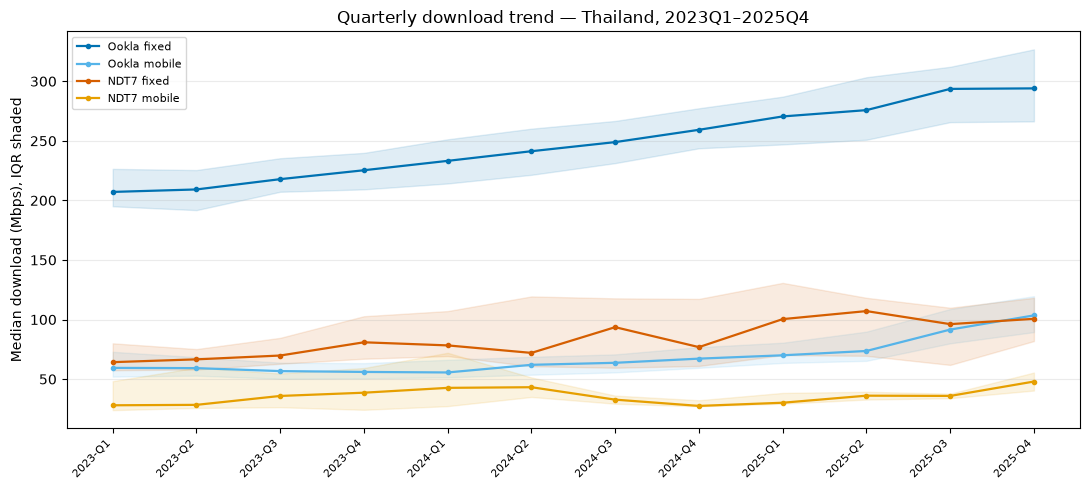

In [7]:
d_stats = quarterly_stats(all_df, 'avg_d_mbps')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, d_stats, 'Median download (Mbps), IQR shaded')
ax.legend(fontsize=8)
ax.set_title('Quarterly download trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Download findings.** All four segments trend up over the 3 years — no segment is flat or
declining:

- **Ookla fixed**: steady, near-linear growth, 207 → 294 Mbps (+42%). The best-resourced,
  least-noisy series here (largest `n_provinces`/`n_tests` of the four).
- **NDT7 fixed**: noisier but the same direction, 64 → ~100 Mbps (+56% by 2025-Q4, peak 107 in
  2025-Q2). Tracks Ookla fixed's *direction* even though the absolute level is ~3x lower (same gap
  RQ1 attributes to NDT7's single-TCP-stream, `lower-bound` methodology vs Ookla's multi-connection
  test).
- **Ookla mobile**: flat through 2023 (~55-60 Mbps), then a real inflection from 2024-Q2 onward,
  reaching 91-104 Mbps by 2025-Q3/Q4 — consistent with a 5G-rollout story rather than measurement
  noise (Ookla mobile has the 2nd-largest sample of the four segments).
- **NDT7 mobile**: bounces 27-48 Mbps with no clean trend — this is the thin-sample segment (2-3
  provinces per quarter after 2024-Q1, see coverage caveat above); don't read a trend into this
  line, it's dominated by which 1-3 provinces happened to qualify that quarter.

**Bottom line: fixed broadband capacity growth is real and monotonic on both platforms; mobile
shows a genuine 2024-2025 speed jump on Ookla, but NDT7 mobile's sample is too thin post-2024-Q1
to confirm or deny the same jump independently.**

### Upload trend

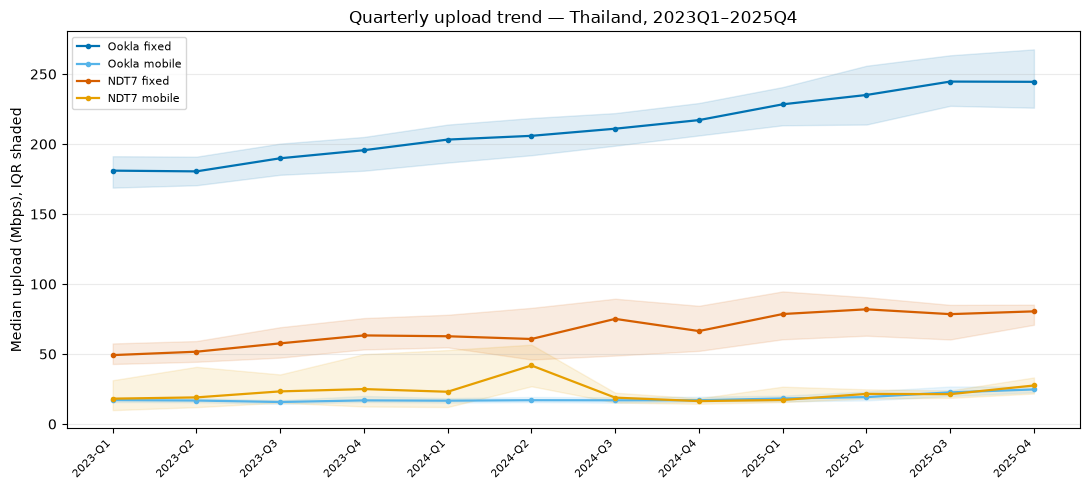

In [8]:
u_stats = quarterly_stats(all_df, 'avg_u_mbps')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, u_stats, 'Median upload (Mbps), IQR shaded')
ax.legend(fontsize=8)
ax.set_title('Quarterly upload trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Upload findings.** Same shape as download, smaller magnitude — Ookla fixed 181 → 245 Mbps
(+35%), NDT7 fixed 49 → 81 Mbps (+63%), both monotonically up. Ookla mobile is flat at ~17 Mbps
through all of 2023-2024, then rises to 23-25 Mbps in 2025 — a smaller but same-direction echo of
the download inflection, supporting the 5G-rollout read rather than a download-only artifact.
NDT7 mobile upload is noisy with no trend (same thin-sample caveat as download).

### Latency trend

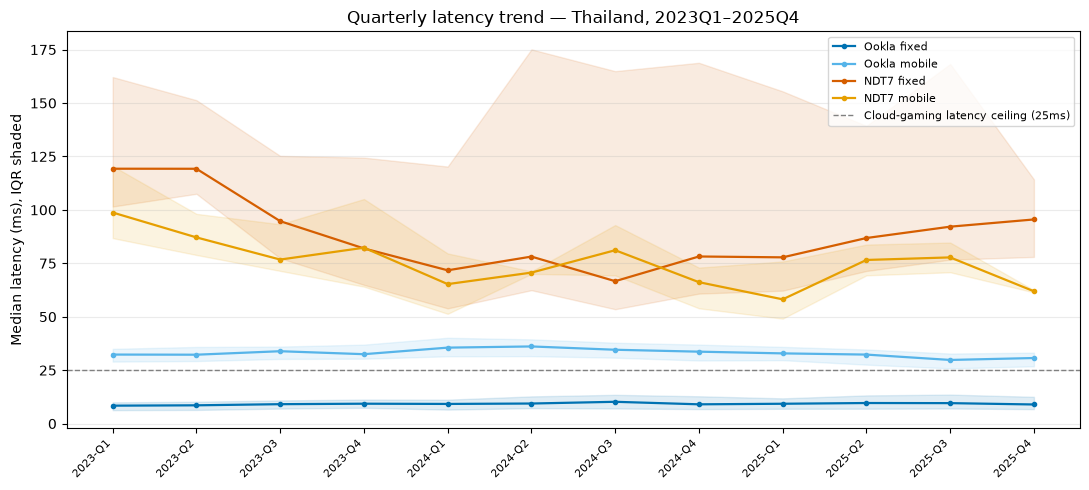

In [9]:
l_stats = quarterly_stats(all_df, 'avg_lat_ms_wt')
fig, ax = plt.subplots(figsize=(11, 5))
plot_trend(ax, l_stats, 'Median latency (ms), IQR shaded')
ax.axhline(25, color='gray', linestyle='--', linewidth=1, label='Cloud-gaming latency ceiling (25ms)')
ax.legend(fontsize=8)
ax.set_title('Quarterly latency trend — Thailand, 2023Q1–2025Q4')
plt.tight_layout()
plt.show()

**Latency findings.** The chart makes RQ1's "0% everywhere" cloud-gaming finding concrete as a
**time-invariant structural gap**, not a snapshot artifact:

- **Ookla fixed** sits at 8-10ms the entire 3 years — already far below the 25ms ceiling, flat (no
  trend either direction, nothing to improve).
- **Ookla mobile** holds at 30-36ms, hovering just above the ceiling with at most a marginal dip in
  late 2025 (33 → 30 → 29 → 31ms) — too small relative to the IQR band to call a real trend.
- **NDT7 fixed and mobile both stay in the 60-120ms range for all 12 quarters**, never once
  approaching the 25ms line — the gap to Ookla is 6-12x and does not close over time. This matches
  RQ1's read: NDT7's RTT is measured to M-Lab's own server infrastructure (Google Cloud PoPs), not
  to a local/regional ISP test server the way Ookla's is, so the latency floor is a **routing/server-
  placement artifact of the M-Lab platform**, not a Thai last-mile quality signal — and 3 years of
  data confirm it's persistent, not transient.

**This is the strongest argument in the whole analysis for why NDT7 latency numbers should not be
read as real-time-application latency (voice/gaming) without the platform-artifact caveat — it's
not a one-quarter fluke.**

### RQ1 revisited over time — Bangkok metro mobile degradation, improving or not?

RQ1 found the Bangkok metro cluster (Bangkok Metropolis, Nonthaburi, Samut Prakan, Pathum Thani)
underperforms on NDT7 mobile UHD pass rate (55-67%) while secondary cities sit at 100%. Given the
coverage collapse noted above, this can only be checked where the cluster has data — mostly
2023-Q1 through 2024-Q1.

In [10]:
BKK_METRO = {'Bangkok Metropolis', 'Nonthaburi', 'Samut Prakan', 'Pathum Thani'}
mobile = all_df[all_df['segment'] == 'NDT7 mobile'].copy()
mobile['group'] = np.where(mobile['province'].isin(BKK_METRO), 'Bangkok metro', 'Rest of Thailand')
mobile['uhd_pass'] = mobile['avg_d_mbps'] >= 25

def weighted_pass_rate(d):
    w = d['total_tests']
    return np.average(d['uhd_pass'], weights=w) * 100

trend = (
    mobile.groupby(['group', 'quarter'], observed=True)
    .apply(lambda d: pd.Series({'uhd_pass_pct': weighted_pass_rate(d), 'n_provinces': d['province'].nunique(), 'n_tests': d['total_tests'].sum()}), include_groups=False)
    .reset_index()
)
trend.pivot(index='quarter', columns='group', values='uhd_pass_pct')

group,Bangkok metro,Rest of Thailand
quarter,,
2023-Q1,0.220959,65.436584
2023-Q2,7.295675,91.746251
2023-Q3,2.031952,100.000000
2023-Q4,3.906419,97.517659
2024-Q1,100.000000,98.006122
2024-Q2,100.000000,NaN
2024-Q3,100.000000,100.000000
2024-Q4,100.000000,NaN
2025-Q1,100.000000,100.000000


**Bangkok-metro-vs-rest findings — the headline result of this Thailand deep-dive (Part B), not of RQ2 as a whole (Part A's SEA-wide growth comparison is the region-level answer).** RQ1's pooled 2023-2025
average (55-67% UHD pass rate for Bangkok metro) hid a sharp step change:

| Period | Bangkok metro | Rest of Thailand |
|---|---|---|
| 2023-Q1 | **0%** | 65% |
| 2023-Q2 | 7% | 92% |
| 2023-Q3 | 2% | 100% |
| 2023-Q4 | 4% | 98% |
| 2024-Q1 onward | **100%** (every quarter) | 98-100% |

Bangkok metro was **effectively failing the UHD threshold entirely through all of 2023** (0-7%,
on a solid 4-province sample each quarter) while the rest of the country was already mostly
passing (65% and climbing to 100% by Q3). Then **at 2024-Q1, Bangkok metro jumps to 100% and stays
there every quarter through 2025-Q4** — a clean, sudden recovery rather than a gradual close.

Caveat: from 2024-Q3 onward both groups run on 1-3 provinces per quarter (coverage-collapse
caveat above applies), so the *sustained* 100% since then is indicative, not statistically tight —
but the **2023 failure → 2024-Q1 recovery transition itself** rests on a decent sample (4 vs 8-13
provinces) and is the reliable part of this finding.

**RQ1's "Bangkok metro underperforms" framing is therefore a 2023 story that had already resolved
by the time of writing (mid-2025) — not an ongoing problem.** Worth flagging as a limitation on
RQ1's headline claim, and worth a footnote on what changed at the 2023/2024 boundary (infra
upgrade? MNO capacity add? seasonal effect from the 2023 sample composition?) if that context is
findable elsewhere in the sourced literature.

## Key Findings (RQ2)

**Part A — SEA-wide (8 countries, equal comparison):**

- **Every country's download median grows over the 3 years** — no country is flat or declining.
  Growth ranges from Philippines' +23.6% (slowest) to Myanmar's +163.8% (fastest).
- **Thailand's +42.0% growth is the 2nd-slowest of the 8** — but this is a high-base/catch-up
  story, not stagnation: the four fastest-growing countries (Myanmar, Cambodia, Vietnam, Laos) all
  start from a much lower 2023 base (20-92 Mbps), and Thailand's absolute download level stays
  2nd-highest of the 8 throughout the entire period, behind only Singapore.
- **Singapore (the only country starting above Thailand) still posts +96.4% growth** — more than
  double Thailand's rate — showing a high base does not mechanically cap growth. Malaysia
  (+79.5% from a lower base than Thailand's) growing nearly 2x faster than Thailand from a lower
  starting point is the sharpest open comparison, flagged for the Discussion section.
- **Region-level (not just country-level) growth also holds up**: breaking each country down into
  its own sub-national regions shows growth is broad-based within every country, not driven by
  one region alone — see the region-by-region breakdown above for all 8 countries individually.

**Part B — Thailand & Vietnam platform deep-dive (Ookla vs NDT7):**

- **Download**: monotonic growth on both fixed platforms (Ookla +42%, NDT7 +56% over 3 years) and
  on Ookla mobile (flat through 2023, +60-80% inflection from 2024-Q2). NDT7 mobile's sample is
  too thin post-2024-Q1 to confirm or deny the same mobile trend independently.
- **Upload**: same shape as download, smaller magnitude, all monotonically up except the
  thin-sample NDT7 mobile line.
- **Latency**: Ookla fixed/mobile sit near/at their app-requirement ceilings the whole 3 years with
  no trend; NDT7 fixed/mobile never approach the 25ms cloud-gaming ceiling in any of the 12
  quarters — a persistent platform-artifact gap (M-Lab server placement), not a closing or
  widening national latency problem.
- **Bangkok metro mobile (RQ1's headline "underperforms" finding) was a 2023-only problem**: 0-7%
  UHD pass rate through all of 2023, then a clean jump to 100% every quarter from 2024-Q1 onward —
  resolved well before this paper was written, not an ongoing issue. Worth a limitation footnote
  on RQ1's headline claim.
- **NDT7 mobile coverage collapses after 2024-Q1** (2-3 provinces/quarter) — read anything past
  that point as indicative, not a population estimate.